In [1]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours
from tqdm.notebook import tqdm
import sys

plt.rcParams["figure.dpi"] = 150

n = 100
t = np.arange(n)

In [65]:
def localized_state(size):
    psi0 = np.zeros(size, dtype = complex)
    beg = int(0.35*size)
    end = int(0.65*size)
    psi0[beg:end] = np.random.uniform(-1, 1, end-beg) + 1j * np.random.uniform(-1, 1, end-beg)
    psi0 /= np.linalg.norm(psi0)
    
    return psi0

def time_evolution(n, N, alpha, beta, kappa):
    neg = np.zeros(n)
    psi0 = localized_state(N)
    rho0 = np.outer(psi0, psi0.conj())
    W0 = wigner_function(rho0).real

    neg[0] = 0.5*np.sum(np.abs(W0)-W0)
    U = diagonalize_floquet_operator(N, alpha, beta, kappa)

    for i, g in enumerate(tqdm(range(n), desc=f"n = {n}")):
        psi = U@psi0
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = 0.5*np.sum(np.abs(W)-W)
        psi0 = psi

    return neg

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

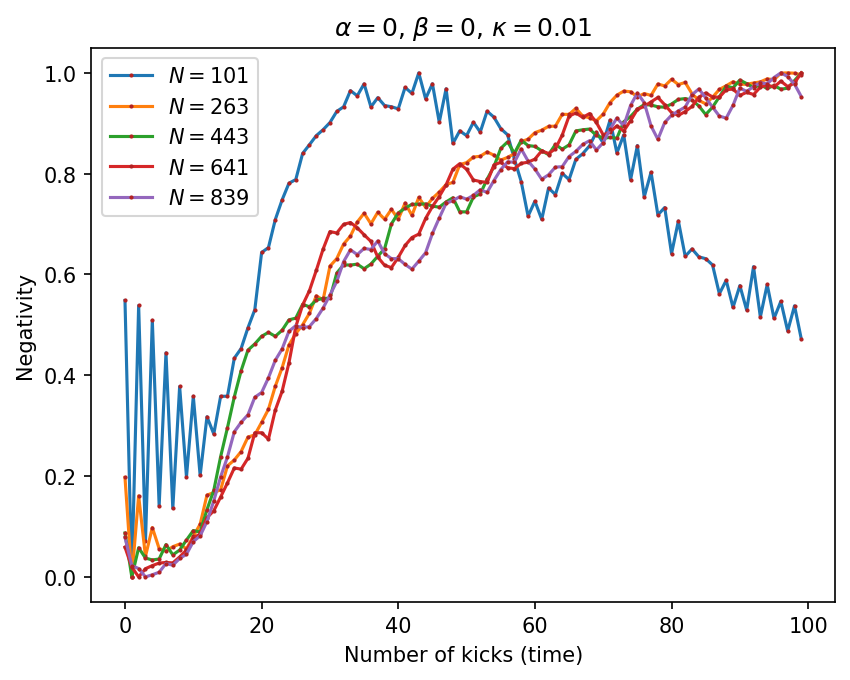

In [3]:
# different sizes

Ns = np.array([101, 263, 443, 641, 839])
alpha = 0; beta = 0
kappa = 0.01

for i in range(len(Ns)):
    neg = time_evolution(n, Ns[i], alpha, beta, kappa)
    neg = (neg - np.min(neg))/(np.max(neg) - np.min(neg))
    plt.plot(t, neg, marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick', label = rf"$N = {Ns[i]}$")
    plt.xlabel("Number of kicks (time)")
    plt.ylabel("Negativity")
    plt.title(rf"$\alpha = {alpha}$, $\beta = {beta}$, $\kappa = {kappa}$")
    plt.legend()
plt.show()

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

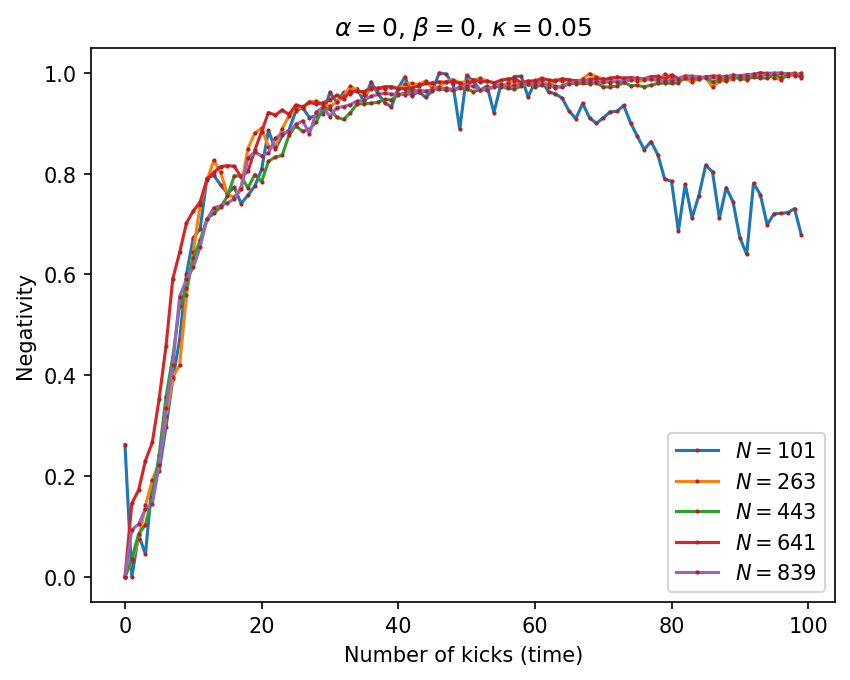

In [4]:
Ns = np.array([101, 263, 443, 641, 839])
alpha = 0; beta = 0
kappa = 0.05

for i in range(len(Ns)):
    neg = time_evolution(n, Ns[i], alpha, beta, kappa)
    neg = (neg - np.min(neg))/(np.max(neg) - np.min(neg))
    plt.plot(t, neg, marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick', label = rf"$N = {Ns[i]}$")
    plt.xlabel("Number of kicks (time)")
    plt.ylabel("Negativity")
    plt.title(rf"$\alpha = {alpha}$, $\beta = {beta}$, $\kappa = {kappa}$")
    plt.legend()
plt.show()

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

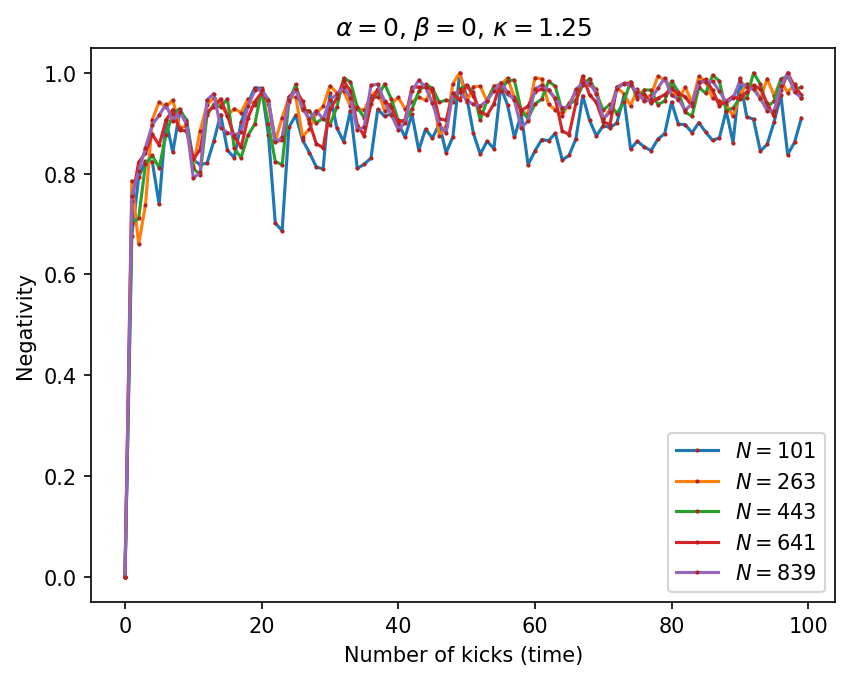

In [5]:
Ns = np.array([101, 263, 443, 641, 839])
alpha = 0; beta = 0
kappa = 1.25

for i in range(len(Ns)):
    neg = time_evolution(n, Ns[i], alpha, beta, kappa)
    neg = (neg - np.min(neg))/(np.max(neg) - np.min(neg))
    plt.plot(t, neg, marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick', label = rf"$N = {Ns[i]}$")
    plt.xlabel("Number of kicks (time)")
    plt.ylabel("Negativity")
    plt.title(rf"$\alpha = {alpha}$, $\beta = {beta}$, $\kappa = {kappa}$")
    plt.legend()
plt.show()

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

n:   0%|          | 0/100 [00:00<?, ?it/s]

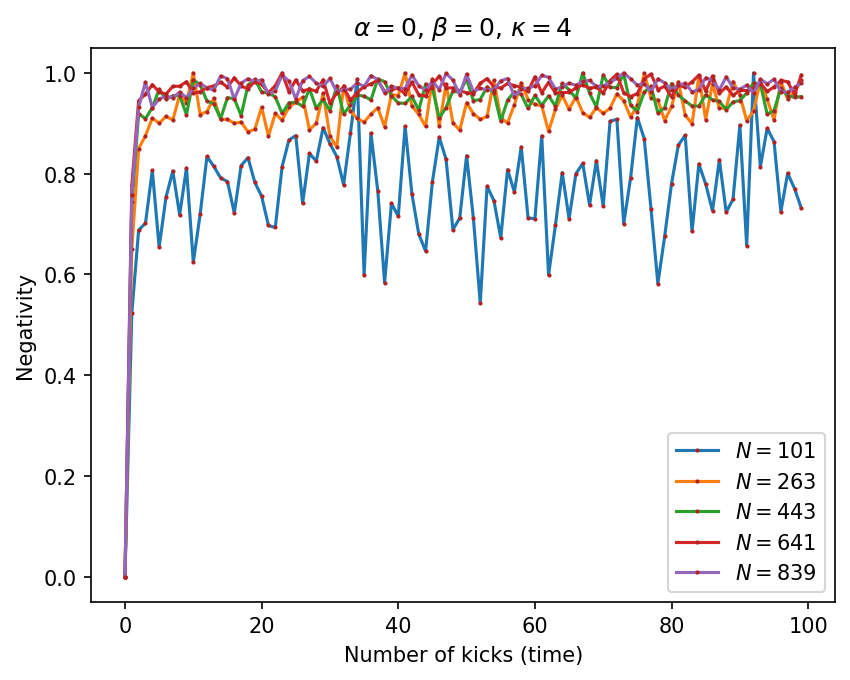

In [6]:
Ns = np.array([101, 263, 443, 641, 839])
alpha = 0; beta = 0
kappa = 4

for i in range(len(Ns)):
    neg = time_evolution(n, Ns[i], alpha, beta, kappa)
    neg = (neg - np.min(neg))/(np.max(neg) - np.min(neg))
    plt.plot(t, neg, marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick', label = rf"$N = {Ns[i]}$")
    plt.xlabel("Number of kicks (time)")
    plt.ylabel("Negativity")
    plt.title(rf"$\alpha = {alpha}$, $\beta = {beta}$, $\kappa = {kappa}$")
    plt.legend()
plt.show()

In [60]:
N = 601
alpha = 0; beta = 0
kappa = 10
n = 100
t = np.arange(n)

neg1 = time_evolution(n, N, alpha, beta, kappa)
neg1 = (neg1 - np.min(neg1))/(np.max(neg1) - np.min(neg1))

n:   0%|          | 0/100 [00:00<?, ?it/s]

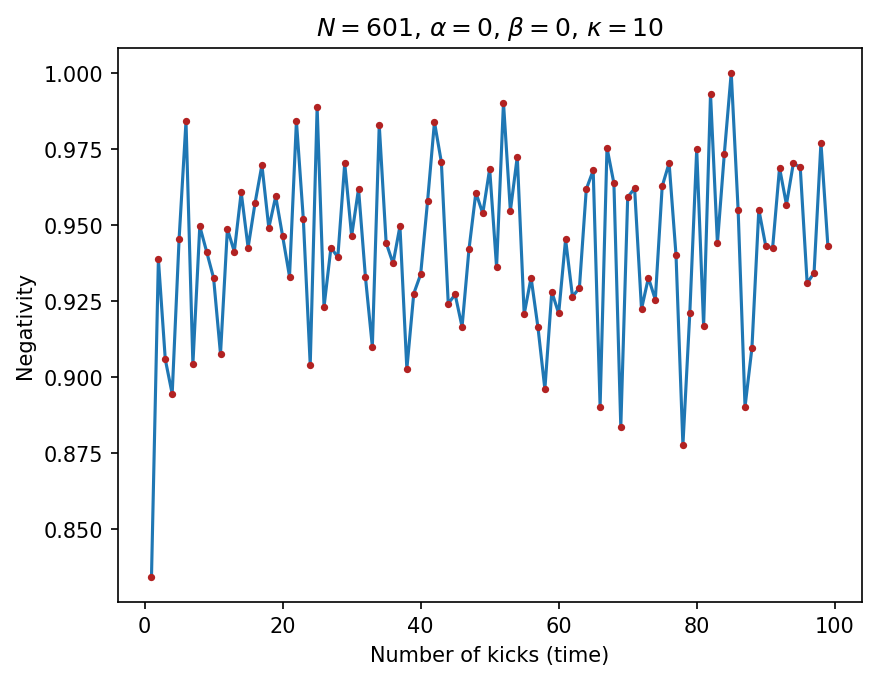

In [61]:
plt.plot(t[1:], neg1[1:], marker = 'o', markersize = 2.5, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick')
plt.xlabel("Number of kicks (time)")
plt.ylabel("Negativity")
plt.title(rf"$N = {N}$, $\alpha = {alpha}$, $\beta = {beta}$, $\kappa = {kappa}$")
plt.show()

Run near integrable case for number of kicks equal to Hilbert space dimension. 

In [62]:
alpha_int = 0; beta_int = 0
alpha_chaotic = 0.2; beta_chaotic = 0.6
kappa_int = 0.01
kappa_chaotic = 10

n = 101:   0%|          | 0/101 [00:00<?, ?it/s]

n = 263:   0%|          | 0/263 [00:00<?, ?it/s]

n = 443:   0%|          | 0/443 [00:00<?, ?it/s]

n = 641:   0%|          | 0/641 [00:00<?, ?it/s]

n = 839:   0%|          | 0/839 [00:00<?, ?it/s]

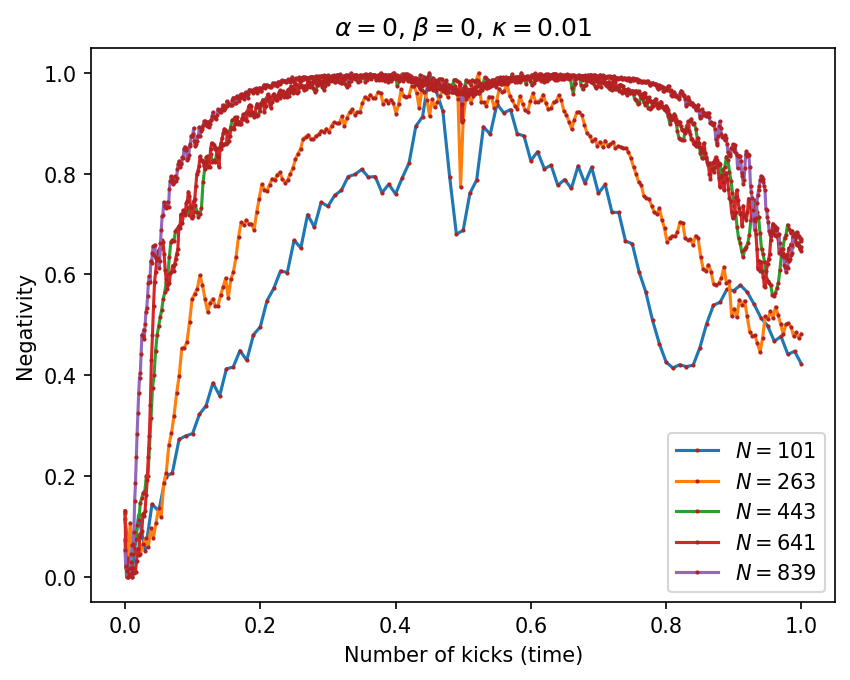

In [66]:
for i in range(len(Ns)):
    n = Ns[i]
    neg = time_evolution(n, Ns[i], beta_int, alpha_int, kappa_int)
    neg = (neg - np.min(neg))/(np.max(neg) - np.min(neg))
    t = np.arange(n)
    t = (t - np.min(t))/(np.max(t) - np.min(t))
    plt.plot(t, neg, marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick', label = rf"$N = {Ns[i]}$")
    plt.xlabel("Number of kicks (time)")
    plt.ylabel("Negativity")
    plt.title(rf"$\alpha = {beta_int}$, $\beta = {alpha_int}$, $\kappa = {kappa_int}$")
    plt.legend()
plt.show()

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

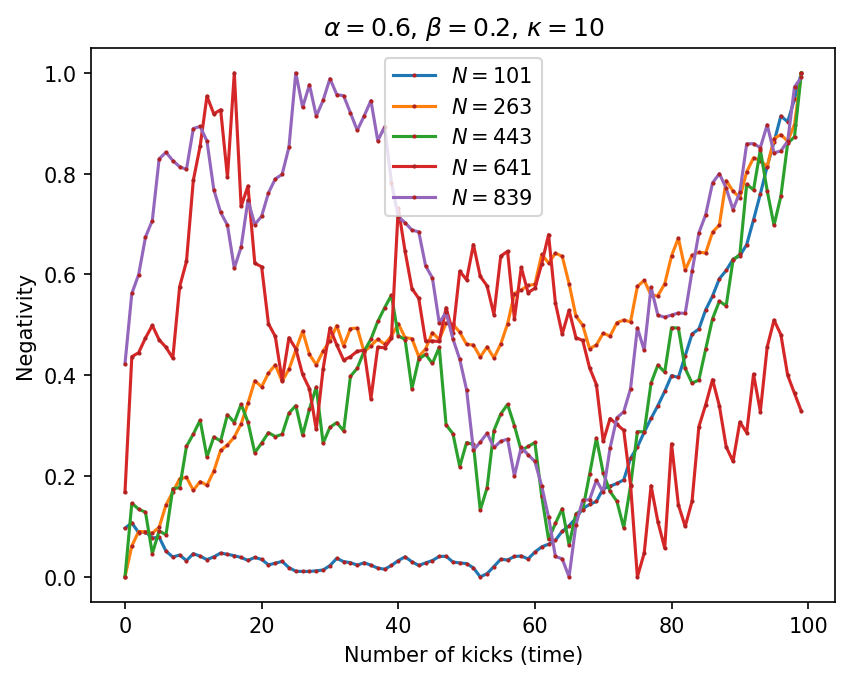

In [68]:
for i in range(len(Ns)):
    n = 100
    neg = time_evolution(n, Ns[i], beta_chaotic, alpha_chaotic, kappa_chaotic)
    neg = (neg - np.min(neg))/(np.max(neg) - np.min(neg))
    t = np.arange(n)
    plt.plot(t, neg, marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick', label = rf"$N = {Ns[i]}$")
    plt.xlabel("Number of kicks (time)")
    plt.ylabel("Negativity")
    plt.title(rf"$\alpha = {beta_chaotic}$, $\beta = {alpha_chaotic}$, $\kappa = {kappa_chaotic}$")
    plt.legend()
plt.show()

In [69]:
def superplot(Ns, alpha, beta, kappa):
    n = 100
    nplots = len(Ns)

    ncols = 3                     # adjust if needed
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4*ncols, 3.5*nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, N in zip(axes, Ns):
        neg = time_evolution(n, N, beta, alpha, kappa)
        neg = (neg - neg.min()) / (neg.max() - neg.min())

        t = np.arange(n)
        ax.plot(t, neg, marker='o', markersize=1,
                markerfacecolor='firebrick',
                markeredgecolor='firebrick')

        ax.set_title(rf"$N={N},\ \alpha={alpha},\ \beta={beta}$")
        ax.set_xlabel("Number of kicks")
        ax.set_ylabel("Negativity")

    # turn off unused panels
    for ax in axes[len(Ns):]:
        ax.axis("off")

    fig.suptitle(rf"$\kappa = {kappa}$", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

n = 100:   0%|          | 0/100 [00:00<?, ?it/s]

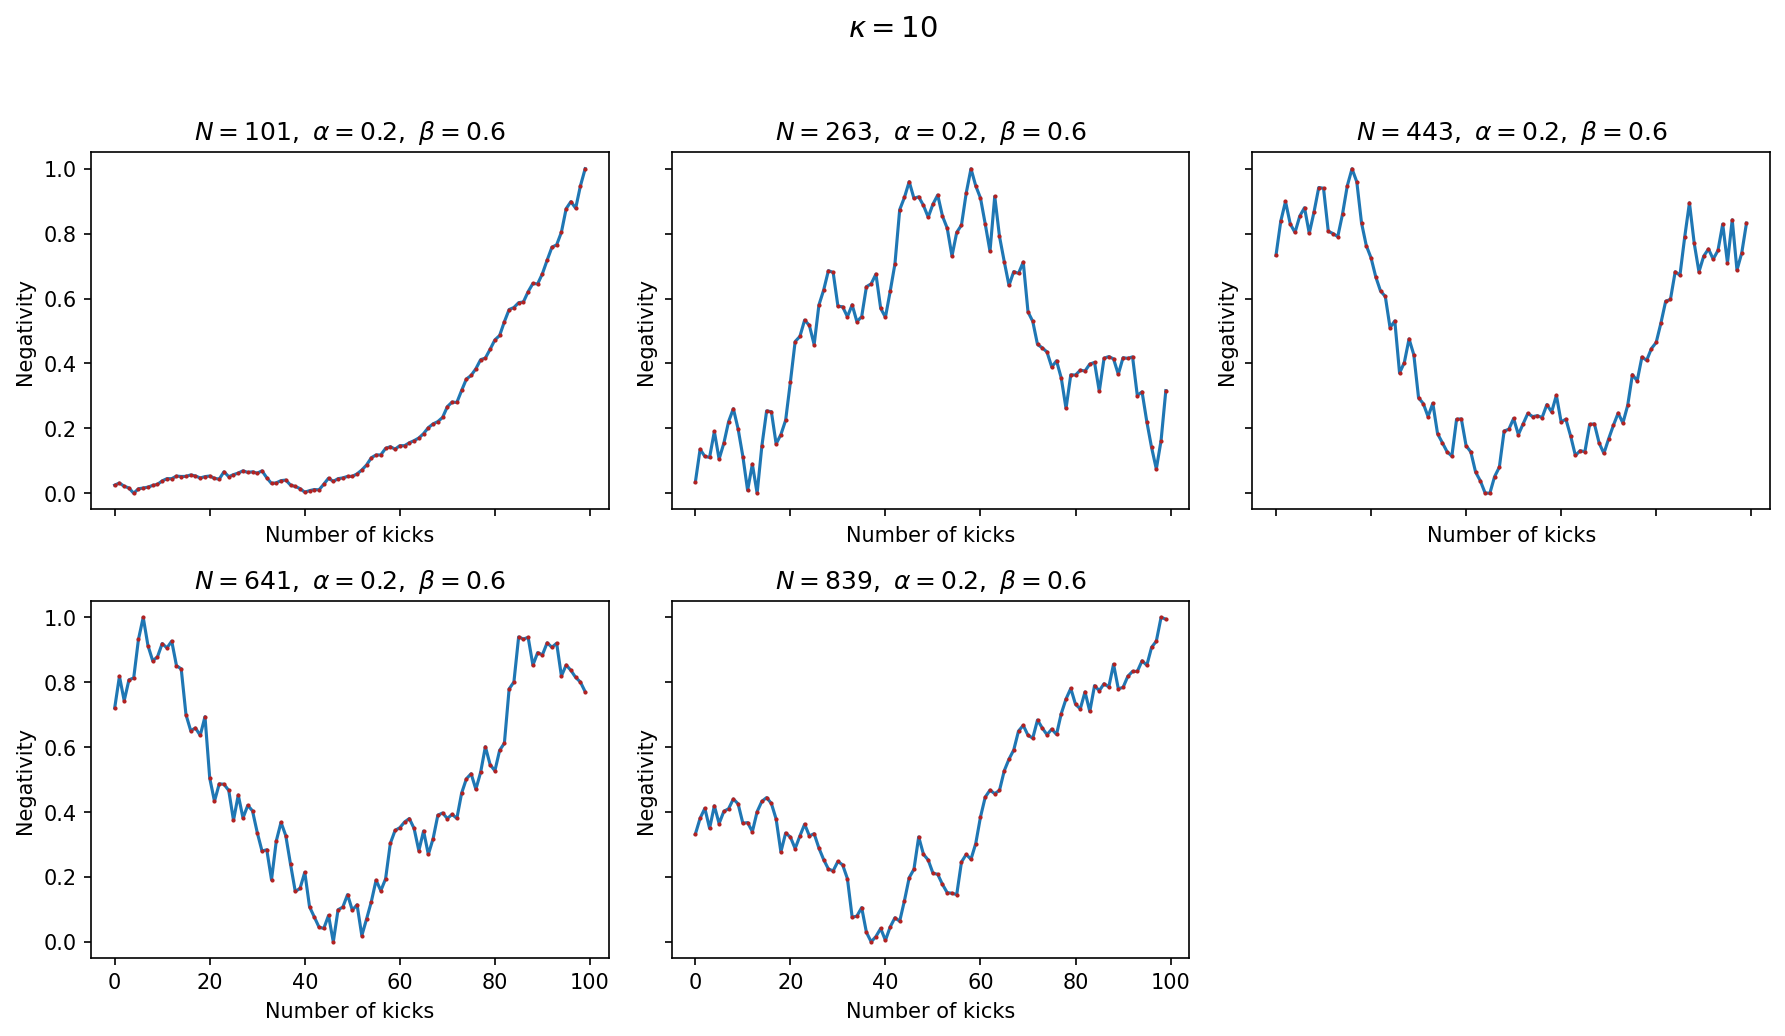

In [70]:
superplot(Ns, alpha_chaotic, beta_chaotic, kappa_chaotic)

In [73]:
def superplot_int(Ns, alpha, beta, kappa):
    nplots = len(Ns)

    ncols = 3                     # adjust if needed
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4*ncols, 3.5*nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, N in zip(axes, Ns):
        n = N
        neg = time_evolution(n, N, beta, alpha, kappa)
        neg = (neg - neg.min()) / (neg.max() - neg.min())

        t = np.arange(n)
        t = (t - np.min(t))/(np.max(t) - np.min(t))
        ax.plot(t, neg, marker='o', markersize=1,
                markerfacecolor='firebrick',
                markeredgecolor='firebrick')

        ax.set_title(rf"$N={N},\ \alpha={alpha},\ \beta={beta}$")
        ax.set_xlabel("Number of kicks")
        ax.set_ylabel("Negativity")

    # turn off unused panels
    for ax in axes[len(Ns):]:
        ax.axis("off")

    fig.suptitle(rf"$\kappa = {kappa}$", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

n = 101:   0%|          | 0/101 [00:00<?, ?it/s]

n = 263:   0%|          | 0/263 [00:00<?, ?it/s]

n = 443:   0%|          | 0/443 [00:00<?, ?it/s]

n = 641:   0%|          | 0/641 [00:00<?, ?it/s]

n = 839:   0%|          | 0/839 [00:00<?, ?it/s]

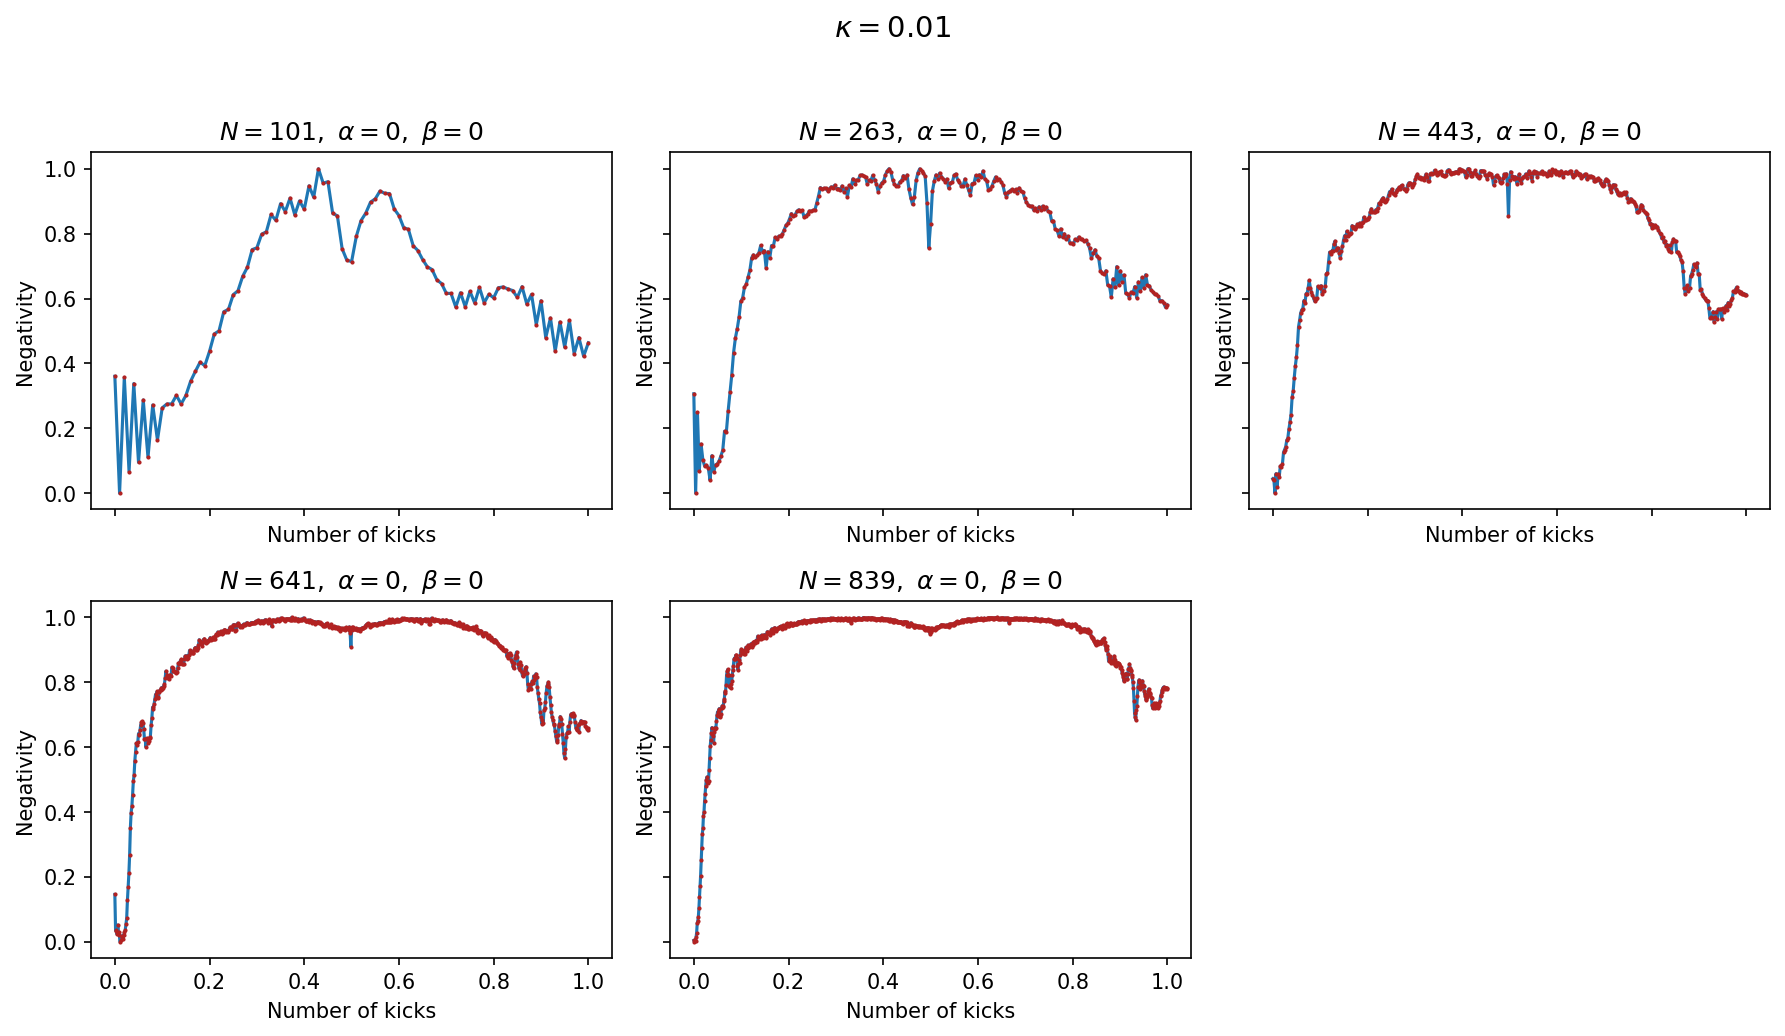

In [74]:
superplot_int(Ns, alpha_int, beta_int, kappa_int)